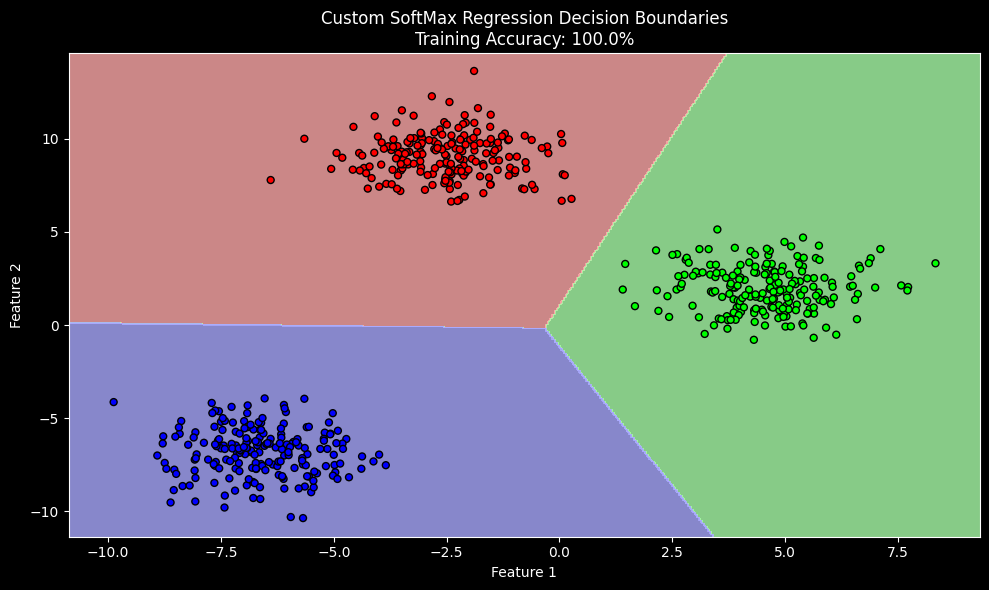

In [1]:
from logreg.softmaxreg import SoftMaxRegression
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs

# 1. Generate a visually distinct 2D dataset with 3 classes
X, y = make_blobs(n_samples=600, centers=3, n_features=2, random_state=42, cluster_std=1.2)

# 2. One-hot encode the target labels (y) to match our class requirements
n_classes = len(np.unique(y))
Y_one_hot = np.zeros((y.shape[0], n_classes))
Y_one_hot[np.arange(y.shape[0]), y] = 1

# 3. Initialize and train your custom model
model = SoftMaxRegression(n_features=X.shape[1], n_labels=n_classes, seed=42)
model.fit(X, Y_one_hot, learning_rate=0.1, batch_size=32, epochs=100)

# 4. Calculate Final Accuracy
predictions = model.predict(X)
y_pred = np.argmax(predictions, axis=1)
accuracy = np.mean(y_pred == y)

# 5. Showcase Visualization: Plotting the Decision Boundary
# Set up a meshgrid covering the feature space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict on every point in the meshgrid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_grid = model.predict(grid_points)
Z_pred = np.argmax(Z_grid, axis=1)
Z_pred = Z_pred.reshape(xx.shape)

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Render the plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_pred, cmap=cmap_light, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=25)

plt.title(f'Custom SoftMax Regression Decision Boundaries\nTraining Accuracy: {accuracy*100:.1f}%')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

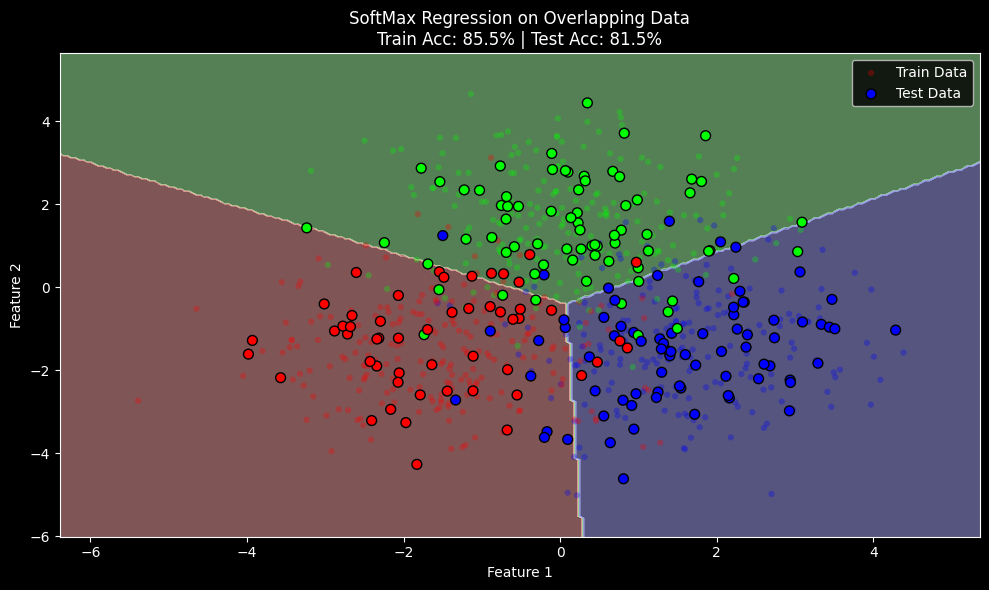

In [4]:
from sklearn.model_selection import train_test_split

# 1. Generate a "harder" dataset
# By forcing the centers closer together and increasing cluster_std,
# the classes will heavily overlap, making 100% accuracy impossible.
X, y = make_blobs(n_samples=800,
                  centers=[[-1.5, -1.5], [0, 1.5], [1.5, -1.5]],
                  n_features=2,
                  random_state=42,
                  cluster_std=1.2) # Increased standard deviation

# 2. Split into Training (75%) and Testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. One-hot encode the TRAINING target labels
n_classes = len(np.unique(y))
Y_train_one_hot = np.zeros((y_train.shape[0], n_classes))
Y_train_one_hot[np.arange(y_train.shape[0]), y_train] = 1

# 4. Initialize and train the model ONLY on the training data
model = SoftMaxRegression(n_features=X_train.shape[1], n_labels=n_classes, seed=42)
model.fit(X_train, Y_train_one_hot, learning_rate=0.1, batch_size=32, epochs=150)

# 5. Evaluate on both sets to check for overfitting/generalization
train_preds = np.argmax(model.predict(X_train), axis=1)
test_preds = np.argmax(model.predict(X_test), axis=1)

train_accuracy = np.mean(train_preds == y_train)
test_accuracy = np.mean(test_preds == y_test)

# 6. Showcase Visualization
# Set up the meshgrid for the background decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_grid = model.predict(grid_points)
Z_pred = np.argmax(Z_grid, axis=1).reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 6))

# Plot the decision boundaries
plt.contourf(xx, yy, Z_pred, cmap=cmap_light, alpha=0.5)

# Plot Training Data (faded, smaller points)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold,
            edgecolor='none', s=20, alpha=0.3, label='Train Data')

# Plot Testing Data (bold, larger points with black edges)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_bold,
            edgecolor='k', s=50, alpha=1.0, label='Test Data')

plt.title(f'SoftMax Regression on Overlapping Data\nTrain Acc: {train_accuracy*100:.1f}% | Test Acc: {test_accuracy*100:.1f}%')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()